In [4]:
import os, sys, glob, jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

#### Slab Models

The following dielectric models were used

| Model    | z={0,10}| z={10,15}| z={15,20}| z={20,25}|  z={25,inf}|
| -------- | ------- | ------- | ------- | ------- | ------- |
| Two-Slab  | 1 or 2 | 1 or 2 | 80 | 80 | 80 |
| Three-Slab  | 2 | 7 | 80 | 80 | 80 |
| Five-Slab  | 2 | 7 | 180 | 210 | 80 |

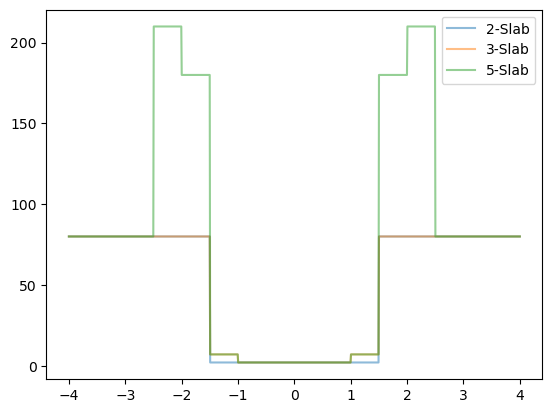

In [32]:
domain = jnp.linspace(-4, 4, 1000)

step = lambda x: jnp.heaviside(x, 0.5)
profile2 = lambda z: 2 + (80-2)*step(jnp.abs(z)-1.5)
profile3 = lambda z: 2 + (7-2)*step(jnp.abs(z)-1.0) + (80-7)*step(jnp.abs(z) - 1.5)
profile5 = lambda z: 2 + (7-2)*step(jnp.abs(z)-1.0) + (180-7)*step(jnp.abs(z) - 1.5) + (210-180)*step(jnp.abs(z)-2.0) + (80-210)*step(jnp.abs(z) - 2.5)

for profile in [profile2, profile3, profile5]:
    plt.plot(domain, profile(domain), alpha=0.5)
plt.legend(['2-Slab', '3-Slab', '5-Slab'])

#### The Born Equation

Can be used to estimate the electrostatic component of Gibbs free energy of solvation for an ion.

$
\Delta G = - \frac{N_A z^2 e^2}{8 \pi \epsilon_0 r_0} (1-\frac{1}{\epsilon_r})
$

In [34]:
import scipy.constants as cons

In [40]:
(cons.Avogadro*cons.elementary_charge*cons.elementary_charge)/(8*cons.pi*cons.epsilon_0)

6.946772877511651e-05

#### Poisson Boltzmann

$
\Delta G = \int_V \rho(r)(\phi_{dielectric}(r) - \phi_{vacuum}(r))dr
$

$\rho$ is the explicit charge distribution of the biomolecular solute\
$\phi$ represents the potentials in vacuum and in the presence of the dielectric


In [43]:
probe_profile = [[-0.002744195159404714, 2.2775777908878796],
[0.043907750656486014, 2.135231215272564],
[0.049396245659630446, 2.135231215272564],
[0.0987924913192608, 2.2775777908878796],
[0.1454445418194867, 2.2775777908878796],
[0.2030734776416664, 2.2775777908878796],
[0.25521402314503644, 1.9928846396572482],
[0.2991217738015225, 1.9928846396572482],
[0.3512623193048927, 2.135231215272564],
[0.39791447448945355, 2.135231215272564],
[0.4473106154647488, 2.2775777908878796],
[0.4994511609681191, 2.135231215272564],
[0.5488475113120845, 2.4199352268507806],
[0.6037322519748596, 2.2775777908878796],
[0.65038419779075, 2.5622818024660967],
[0.7025247432941205, 2.7046283780814124],
[0.7491766891100111, 2.8469749536967486],
[0.8013172346133813, 2.8469749536967486],
[0.8534577801167517, 3.274025540890291],
[0.9055983256201215, 3.701065267736249],
[0.9495060762766075, 4.128115854929792],
[0.9989022172519029, 4.839859593353976],
[1.0482985675958687, 5.409256756162835],
[1.0976949179398336, 6.12100049458702],
[1.1553238537620134, 6.975090808626541],
[1.2019757995779043, 7.971522268107579],
[1.2568605402406792, 8.967975448283768],
[1.3007682908971652, 10.249110919343023],
[1.3968165870570213, 14.946623937081664],
[1.4434687422415824, 17.6512468849893],
[1.498353482904357, 21.77936273991908],
[1.5450054287202482, 27.18861406590813],
[1.5998901693830228, 34.44839802576529],
[1.6465423245675836, 44.412810363703876],
[1.6986826607022836, 56.08541147498215],
[1.7425906207274398, 62.77580098711735],
[1.805707946868429, 66.6192182606427],
[1.8468715023655105, 68.46975089451082],
[1.893523657550071, 70.7473259703118],
[1.9484081888441758, 72.74021332505593],
[2.0032929295069506, 73.45195706348012],
[2.041712499213297, 75.30249105489169],
[2.096597239876072, 76.01423479331588],
[2.189901131507854, 77.43772227016424],
[2.1432491856919627, 76.72597853174005],
[2.242041886379894, 78.00711807542966],
[2.2859494276677093, 78.43416323244941],
[2.343578572858559, 79.1459069708736],
[2.3957189089932593, 79.71530006105212],
[2.4478596638653003, 80],
[2.494511609681191, 80],
[1.350164641241131, 12.384342134615567]]

In [47]:
probe_profile = jnp.array(sorted(probe_profile))

In [65]:
from scipy.interpolate import CubicSpline as spline
my_spline = spline(probe_profile[:,0], probe_profile[:, 1], bc_type=('natural', 'natural'), extrapolate=True)
eff_dielectric = lambda z: my_spline(jnp.abs(z))

array([-0.08114987])

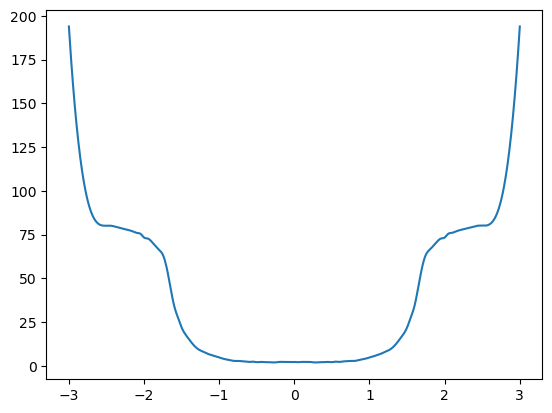

In [69]:
domain = jnp.linspace(-3., 3, 1000)
plt.plot(domain, eff_dielectric(domain))

In [41]:
#Determine the delta G profile of a test charge in the implicit membranes by solving PB equation numerically
probe_radius = 2 #angstroms
res = 0.5 #angstroms

In [ ]:
# make a grid of 8 by 8 by 8 nanometers with 0.5 angstrom resolution
charge = jnp.zeros(())